# Feature Importance Analysis Using Random Forest
---
The implementation of the Random Forest algorithm on the dataset and the previously identified clusters is mainly performed to evaluate the importance of the features that determine which cluster a user belongs to.
Furthermore, this approach can be extended to the point where it becomes possible to predict the potential profile of a single user based on their characteristics.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

At this stage, we are examining the initially cleaned dataset, but we have already added the 'cluster' feature, which is the result of the PCA and K-Means process. We used PCA to reduce the dimensionality of the data, and then applied K-Means to assign a cluster to each user.

In [2]:
data = pd.read_csv('../dataset/data_clusters.csv')
data

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,0
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1
3,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0
4,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8631,C19184,5.871712,0.500000,20.90,20.90,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,1,500.0,58.644883,43.473717,0.000000,6,0
8632,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6,1
8633,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6,1
8634,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6,0


We remove the CUST_ID column because it is not needed and cannot be used in the implementation of the Random Forest algorithm. After that, we separate the target column, which in this case is the 'cluster' column

In [3]:
X = data.drop(['cluster', 'CUST_ID'], axis=1)
y = data['cluster']

We split the data into training and testing sets in order to evaluate how well the algorithm performs after training.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

We initialize the Random Forest algorithm.

In [5]:
model = RandomForestClassifier(n_estimators=200,random_state=42)

We train the algorithm on the dataset. One hypothesis is that even if the model overfits the data, it would not be a major issue, since our primary goal is to analyze feature importances, rather than to accurately predict a specific cluster.

Although initializing an entire algorithm just to obtain the results for feature importances may raise the question of whether it is truly worth it.

In [6]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Despite the goals of the project, we will examine the metrics that indicate how well the algorithm has performed.

In [7]:
predictions = model.predict(X_test)
predictions

array([0, 0, 1, ..., 1, 0, 2], shape=(1728,))

accuracy_score

$$\LARGE
    Accuracy = \frac{\text{Number of correct predictions}}{\text{Total number of predictions}}
$$

or

$$
    Accuracy = \frac{\text{TP + TN}}{\text{TP + TN + FP + FN}}
$$

where:

TP - True positive

TN - True negative

FP - False positive

FN - False negative

If we have multi - class like our case:

$$
\LARGE
Accuracy = \frac{\sum_{i=1}^{n} \text{correct predictions}}{N}
$$

Where:

N - total number of observations

In [8]:
accuracy = accuracy_score(y_test, predictions)
print(accuracy)

0.9675925925925926


### Evaluation Metrics for Classification Models

$$\LARGE
    Precision = \frac{TP}{TP + FP}
$$

Where:

TP - True Positive

FP - False Positive

-> True Positive (TP) shows how many times the model correctly predicted the positive class when it was actually positive.

$$\LARGE
Recall = \frac{TP}{TP + FN}
$$

Where:

TP - True Positive

FN - False Negative

-> Recall shows how many of the actual positive cases the model correctly identified.

$$\LARGE
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

-> F1-score measures the balance between Precision and Recall. It is used when we want a single metric that combines both.

In [9]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       773
           1       0.97      0.97      0.97       655
           2       0.97      0.95      0.96       233
           3       0.95      0.88      0.91        67

    accuracy                           0.97      1728
   macro avg       0.96      0.95      0.95      1728
weighted avg       0.97      0.97      0.97      1728



We initialized a confusion matrix to evaluate how well the model performed across the different classes.

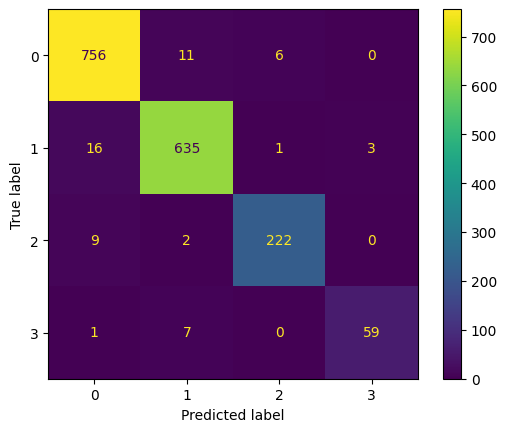

In [10]:
cm = confusion_matrix(y_test, predictions)

ConfusionMatrixDisplay(cm).plot()
plt.show()

In [11]:
cm = confusion_matrix(y_test, predictions)

for i in range(cm.shape[0]):
    fp = cm[:, i].sum() - cm[i, i]
    print(f"Class {i} FP:", fp)

Class 0 FP: 26
Class 1 FP: 20
Class 2 FP: 7
Class 3 FP: 3


In [12]:
# class 3
round(3 / 62, 2) * 100

5.0

In [13]:
# class 2
round(7 / 229, 2) * 100

3.0

In [14]:
# class 1
round(20 / 655, 2) * 100

3.0

In [15]:
# class 0
round(26 / 782, 2) * 100

3.0

At the end of this experiment, we will also examine the feature importances. They will help us identify several features to analyze in more detail in order to gain a better understanding of the specific users.

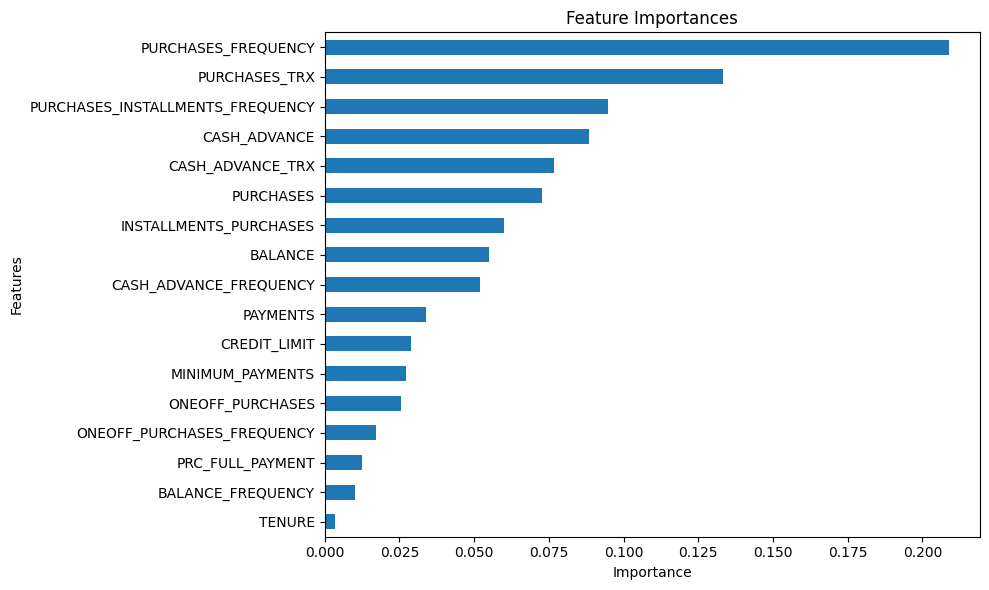

In [16]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10,6))

importance.plot(kind="barh")

plt.title("Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()